In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from rpasim.gyms import IFFL2VarsGym

## Setup

Base parameters: alpha=1, delta=0.1, beta=1, gamma=1

Control alpha and beta together (both scaled by u) to simulate a step change in the input signal.

Expected steady states:
- $x_{ss} = \frac{\alpha}{\delta} u$
- $y_{ss} = \frac{\beta \delta}{\alpha \gamma}$ (independent of u — RPA)

In [24]:
alpha, delta, beta, gamma = 1.0, 0.1, 1.0, 1.0

env = IFFL2VarsGym(
    reward_fn=lambda state, time: torch.tensor(0.0),
    initial_state=torch.tensor([0.0, 0.0]),
    time_horizon=50.0,
    dt=0.1,
    n_reward_steps=3000,
    controlled_params=["alpha", "beta"],
    action_low=0.5,
    action_high=2.0,
    ode_method="rk4",
)

In [43]:
obs, _ = env.reset()
observations = [obs.copy()]
times = [0.0]

n_steps_u1 = 100   # u=1 for 5s
n_steps_u2 = 500  # u=2 for 15s

u1 = 1.0
u2 = 0.5

# Phase 1: u = 1 (multiplier = 1 for both alpha and beta)
for _ in range(n_steps_u1):
    action = np.array([u1, u1], dtype=np.float32)
    obs, reward, terminated, truncated, info = env.step(action)
    observations.append(obs.copy())
    times.append(env.current_time)
    if terminated or truncated:
        break

# Phase 2: u = 2 (multiplier = 2 for both alpha and beta)
for _ in range(n_steps_u2):
    action = np.array([u2, u2], dtype=np.float32)
    # action = np.array([2.0, 2.0], dtype=np.float32)
    obs, reward, terminated, truncated, info = env.step(action)
    observations.append(obs.copy())
    times.append(env.current_time)
    if terminated or truncated:
        break

observations = np.array(observations)
times = np.array(times)

In [44]:
# Expected steady states
x_ss_u1 = alpha / delta * u1
x_ss_u2 = alpha / delta * u2
y_ss = beta * delta / (alpha * gamma)

print(f"Expected x_ss (u=1): {x_ss_u1}")
print(f"Expected x_ss (u=2): {x_ss_u2}")
print(f"Expected y_ss (both): {y_ss}")

Expected x_ss (u=1): 10.0
Expected x_ss (u=2): 5.0
Expected y_ss (both): 0.1


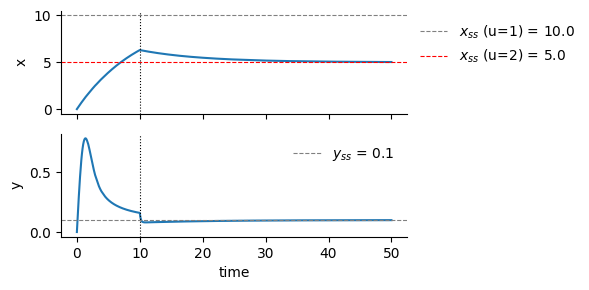

In [45]:
fig, (ax_x, ax_y) = plt.subplots(2, 1, figsize=(6, 3), sharex=True)

ax_x.plot(times, observations[:, 0])
ax_x.axhline(x_ss_u1, color="gray", ls="--", lw=0.8, label=f"$x_{{ss}}$ (u=1) = {x_ss_u1}")
ax_x.axhline(x_ss_u2, color="red", ls="--", lw=0.8, label=f"$x_{{ss}}$ (u=2) = {x_ss_u2}")
ax_x.axvline(n_steps_u1 * 0.1, color="black", ls=":", lw=0.8)
ax_x.set_ylabel("x")
ax_x.legend(frameon=False, bbox_to_anchor=(1, 1))
sns.despine(ax=ax_x)

ax_y.plot(times, observations[:, 1])
ax_y.axhline(y_ss, color="gray", ls="--", lw=0.8, label=f"$y_{{ss}}$ = {y_ss}")
ax_y.axvline(n_steps_u1 * 0.1, color="black", ls=":", lw=0.8)
ax_y.set_ylabel("y")
ax_y.set_xlabel("time")
ax_y.legend(frameon=False, bbox_to_anchor=(1, 1))
sns.despine(ax=ax_y)

fig.tight_layout()

In [46]:
# Verify steady states
tol = 0.5

# Check x converges to x_ss_u2 after step change
x_final = observations[-1, 0]
assert abs(x_final - x_ss_u2) < tol, f"x did not converge: {x_final:.3f} vs expected {x_ss_u2}"

# Check y returns to y_ss (RPA)
y_final = observations[-1, 1]
assert abs(y_final - y_ss) < tol, f"y did not adapt: {y_final:.3f} vs expected {y_ss}"

print(f"x_final = {x_final:.4f} (expected {x_ss_u2}) ✓")
print(f"y_final = {y_final:.4f} (expected {y_ss}) ✓")
print("Steady state assertions passed!")

x_final = 5.0253 (expected 5.0) ✓
y_final = 0.0995 (expected 0.1) ✓
Steady state assertions passed!
